# **Insurace Cost Prediction**
                          - by Tarun Dhakshinamoorthy

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/insCostPred(1).csv')

Table of Contents

1. Import Libraries

2. Load the Dataset

3. Exploratory Data Analysis (EDA)
   3.1 Dataset Overview

   3.2 Missing Value Analysis

   3.3 Duplicate Value Analysis

   3.4 Statistical Summary

   3.5 Data Type Analysis

   3.6 Target Variable Analysis

   3.7 Numerical Feature Analysis

   3.8 Categorical Feature Analysis

   3.9 Correlation Analysis

   3.10 Outlier Detection

   3.11 Relationship Between Features and Target

   3.12 EDA Summary

4. Data Preprocessing
   4.1 Feature and Target Selection

   4.2 Identification of Numerical and Categorical Features

   4.3 Train-Test Split

   4.4 One-Hot Encoding

5. Model Building
   5.1 Linear Regression

   5.2 Ridge Regression

   5.3 Lasso Regression

   5.4 Decision Tree

   5.5 Random Forest

   5.6 Gradient Boosting
   
   5.7 X.G boosting

6. Hyperparameter Tuning

7. Model Performance Evaluation

8. Model Comparison

9. Final Model Selection

10. Feature Importance Analysis

11. Model Saving

12. Model Comparison Report

13. Challenges Faced and Techniques Used

14. Business Recommendations

15. Conclusion

In [27]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'Classroom',
 'IMG_20200920_200128.jpg',
 'IREDA-Indias-Green-Energy-Catalyst.gslides',
 'IREDA_Presentation.gslides',
 'IT-PROJECT-MANAGEMENT-PPT.gslides',
 'Untitled presentation.gslides',
 'Screenshot_2025-07-04-19-38-46-03_e4424258c8b8649f6e67d283a50a2cbc.jpg',
 'cognizant quiz',
 'deep learning',
 'Tarun_Data_Science_CV_Final.pdf',
 '2.pdf',
 '1.pdf',
 'Saved from Chrome',
 '.DS_Store',
 'bank-additional-names.txt',
 'bank-additional-full.csv',
 'bank-additional.csv',
 '.Rhistory',
 'PortugeseBank',
 'Flight_Fare_Prediction.ipynb',
 'Document from Tarun',
 'insCostPred(1).csv']

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [29]:
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [30]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [31]:
print("rows=", df.shape[0])
print("Columns=",df.shape[1])

rows= 1338
Columns= 7


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [33]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [34]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


Missing Value Analysis

In [35]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Duplicate Value Analysis

In [36]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 1


In [37]:
df = df.drop_duplicates()

In [38]:
df.shape

(1337, 7)

In [39]:
for column in df.columns:
    print(column)
    print(df[column].unique())
    print("-"*50)

age
[19 18 28 33 32 31 46 37 60 25 62 23 56 27 52 30 34 59 63 55 22 26 35 24
 41 38 36 21 48 40 58 53 43 64 20 61 44 57 29 45 54 49 47 51 42 50 39]
--------------------------------------------------
sex
['female' 'male']
--------------------------------------------------
bmi
[27.9   33.77  33.    22.705 28.88  25.74  33.44  27.74  29.83  25.84
 26.22  26.29  34.4   39.82  42.13  24.6   30.78  23.845 40.3   35.3
 36.005 32.4   34.1   31.92  28.025 27.72  23.085 32.775 17.385 36.3
 35.6   26.315 28.6   28.31  36.4   20.425 32.965 20.8   36.67  39.9
 26.6   36.63  21.78  30.8   37.05  37.3   38.665 34.77  24.53  35.2
 35.625 33.63  28.    34.43  28.69  36.955 31.825 31.68  22.88  37.335
 27.36  33.66  24.7   25.935 22.42  28.9   39.1   36.19  23.98  24.75
 28.5   28.1   32.01  27.4   34.01  29.59  35.53  39.805 26.885 38.285
 37.62  41.23  34.8   22.895 31.16  27.2   26.98  39.49  24.795 31.3
 38.28  19.95  19.3   31.6   25.46  30.115 29.92  27.5   28.4   30.875
 27.94  35.09  29.7   35.7

Seperating Numerical And Categorical

In [40]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include='object').columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['age', 'bmi', 'children', 'charges'], dtype='object')

Categorical Columns:
Index(['sex', 'smoker', 'region'], dtype='object')


**Exploratory Data Analysis**

Distribution of the Target Variable


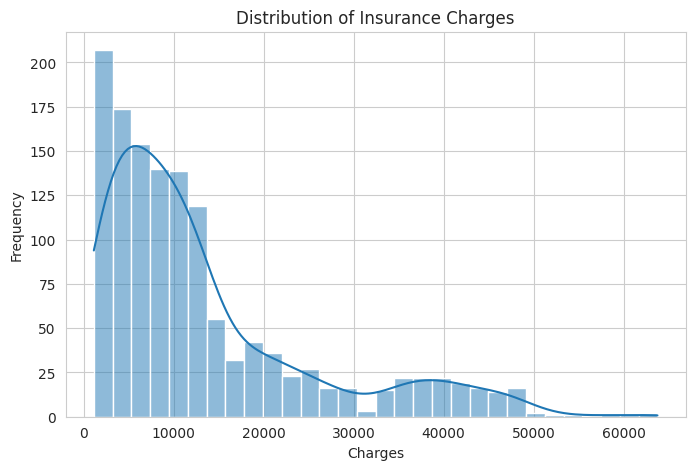

In [41]:
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], bins=30, kde=True)

plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

Numerical Feature Distribution

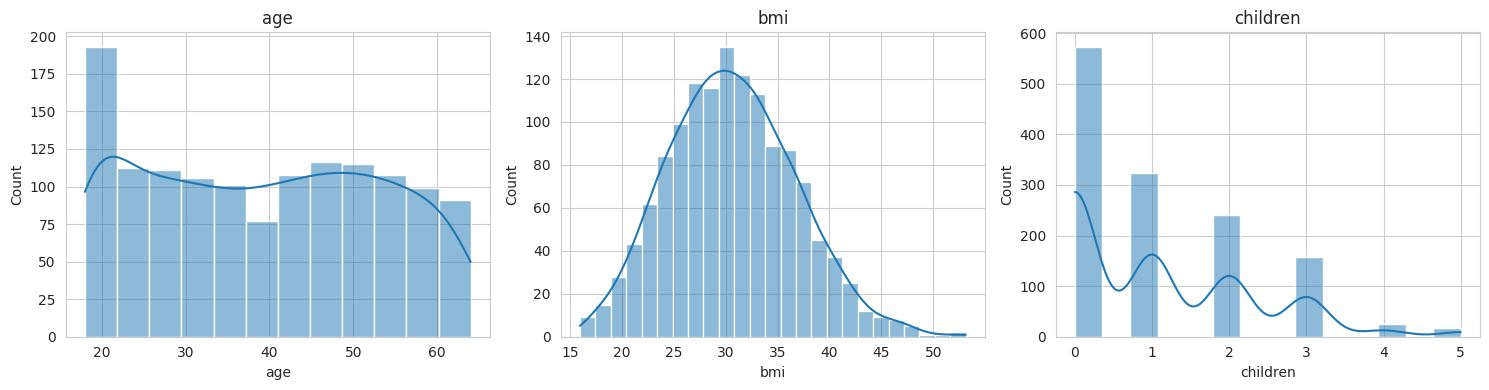

In [42]:
num_cols = ['age', 'bmi', 'children']

plt.figure(figsize=(15,4))

for i, col in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

Categorical Feature Distribution

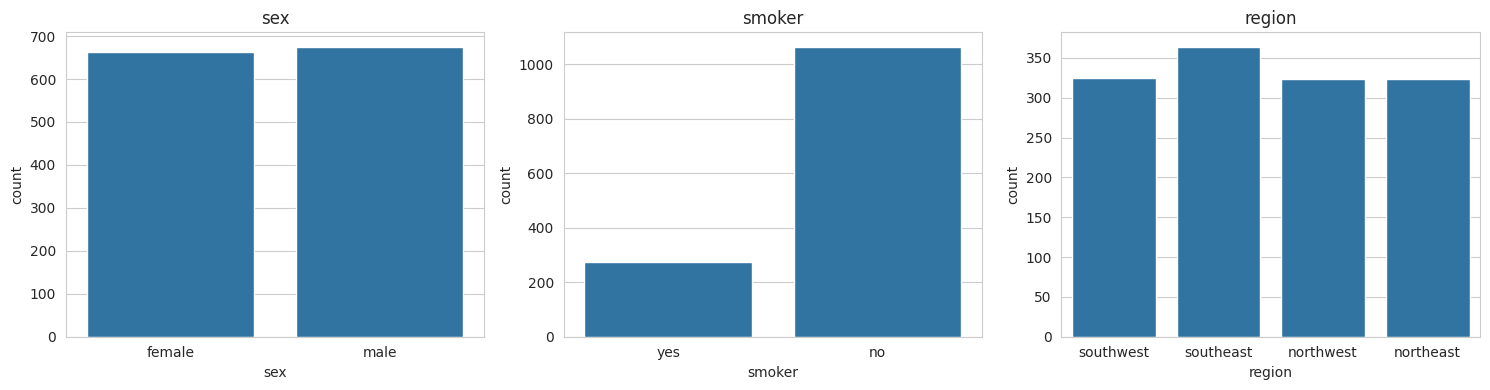

In [43]:
cat_cols = ['sex', 'smoker', 'region']

plt.figure(figsize=(15,4))

for i, col in enumerate(cat_cols):
    plt.subplot(1,3,i+1)
    sns.countplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Outlier Detection

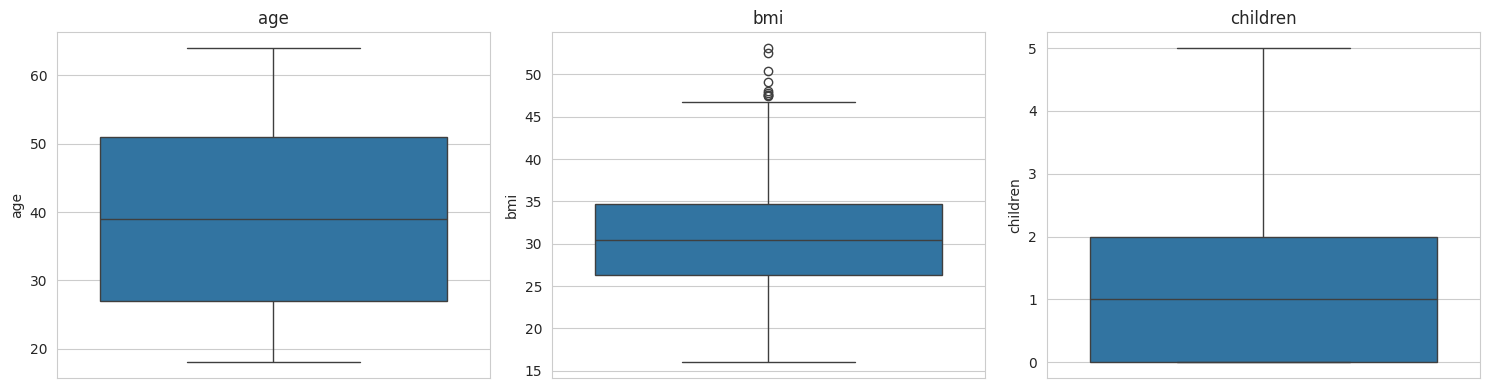

In [44]:
plt.figure(figsize=(15,4))

for i, col in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Correlation Heatmap

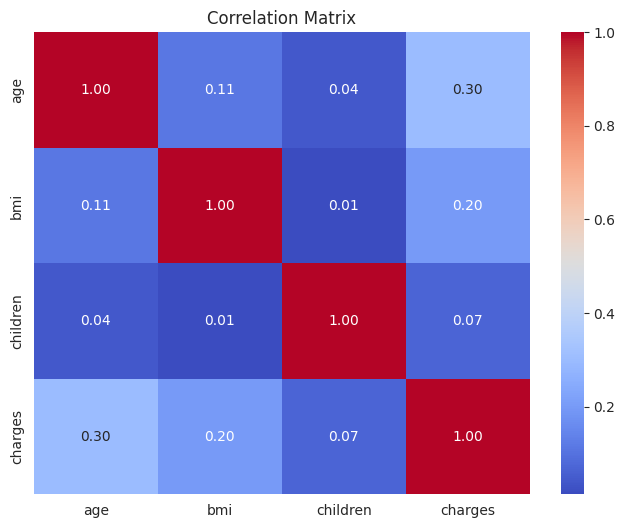

In [45]:
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Matrix")
plt.show()

Charges vs Numerical Features
Age

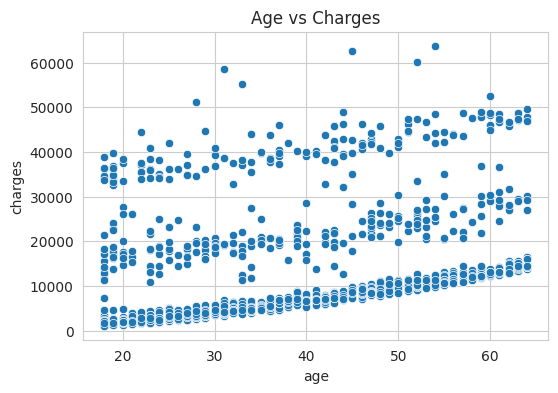

In [46]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='charges', data=df)

plt.title('Age vs Charges')
plt.show()

Body Mass Index

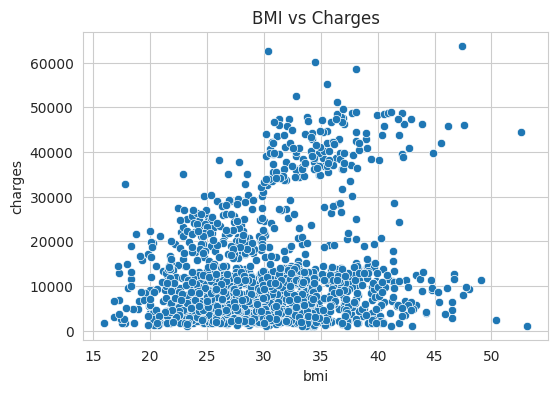

In [47]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='bmi', y='charges', data=df)

plt.title('BMI vs Charges')
plt.show()

Children Vs Charges

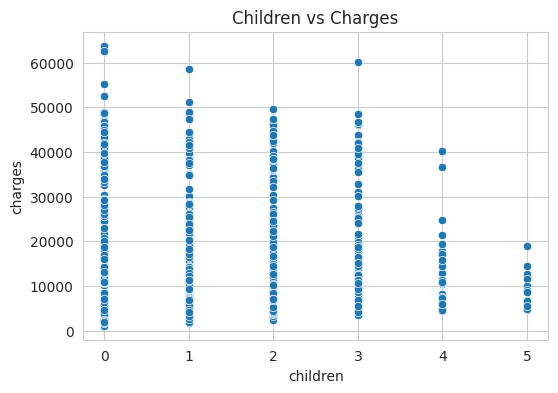

In [48]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='children', y='charges', data=df)

plt.title('Children vs Charges')
plt.show()

**Charges vs Categorical Features**

Sex

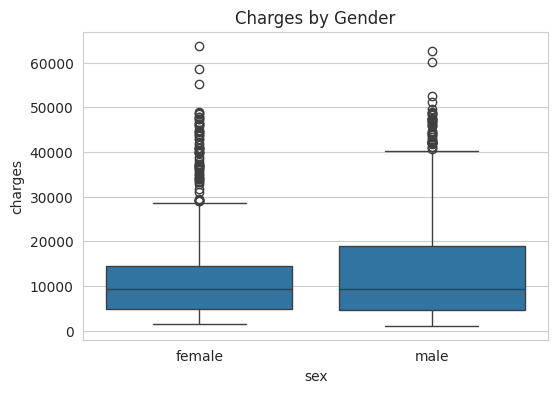

In [49]:
plt.figure(figsize=(6,4))
sns.boxplot(x='sex', y='charges', data=df)

plt.title('Charges by Gender')
plt.show()

Smoker

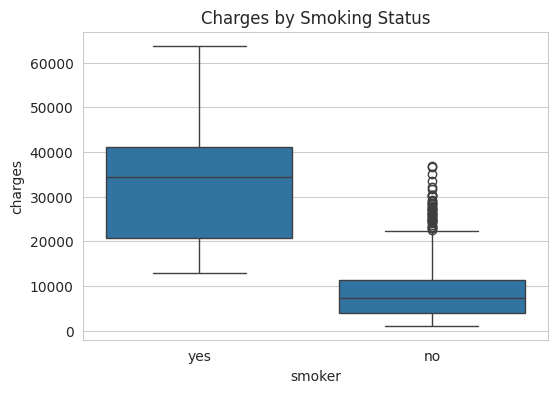

In [50]:
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='charges', data=df)

plt.title('Charges by Smoking Status')
plt.show()

Region

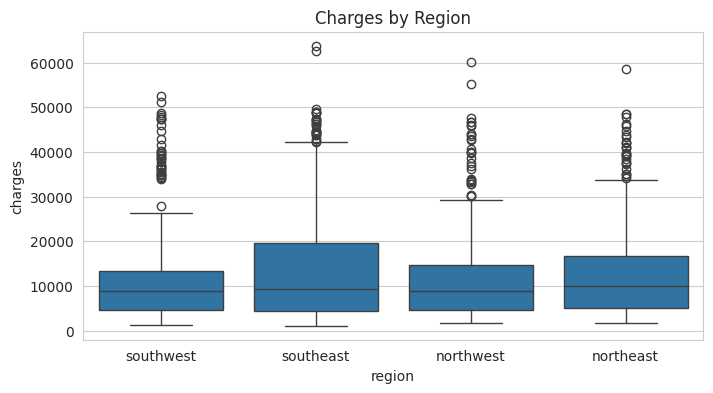

In [51]:
plt.figure(figsize=(8,4))
sns.boxplot(x='region', y='charges', data=df)

plt.title('Charges by Region')
plt.show()

Pairplot for a quick overview of relationships among numerical Variable

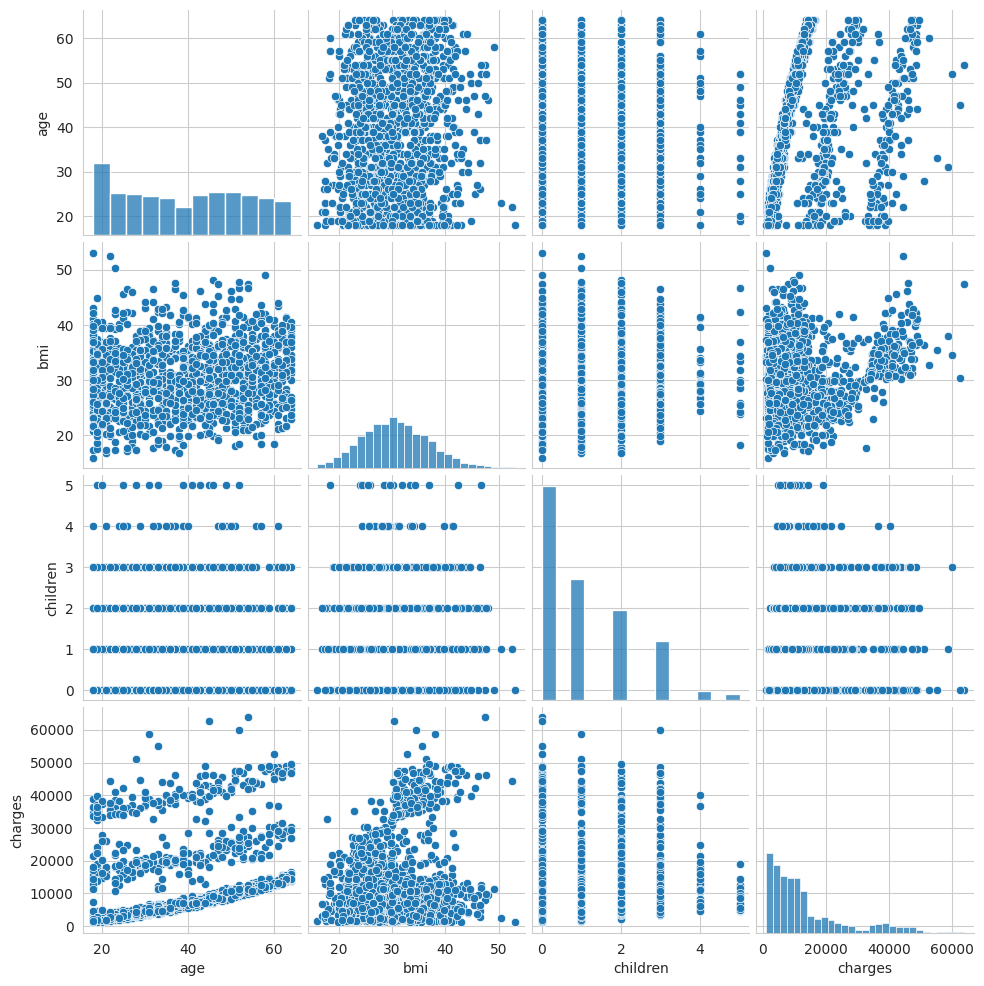

In [52]:
sns.pairplot(df)
plt.show()

# **Data Preprocessing**

In [54]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [55]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

Seperating Features and Target

In [56]:
X = df.drop('charges', axis=1)
y = df['charges']

In [57]:
categorical_features = X.select_dtypes(include='object').columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Features:", list(categorical_features))
print("Numerical Features:", list(numerical_features))

Categorical Features: ['sex', 'smoker', 'region']
Numerical Features: ['age', 'bmi', 'children']


Train - Test - Split

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Creating the Preprocessor

In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='passthrough'
)

Building The model

In [63]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

**Linear regression**

In [65]:
linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred_lr = linear_model.predict(X_test)

In [66]:
print("Linear Regression Performance")
print("-"*35)

print("MAE :", mean_absolute_error(y_test, y_pred_lr))
print("MSE :", mean_squared_error(y_test, y_pred_lr))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R² Score :", r2_score(y_test, y_pred_lr))

Linear Regression Performance
-----------------------------------
MAE : 4177.045561036319
MSE : 35478020.675235525
RMSE : 5956.342894363581
R² Score : 0.8069287081198016


**Ridge Regression**

In [70]:
ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

In [69]:
print("Ridge Regression Performance")
print("-"*35)

print("MAE :", mean_absolute_error(y_test, y_pred_ridge))
print("MSE :", mean_squared_error(y_test, y_pred_ridge))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R² Score :", r2_score(y_test, y_pred_ridge))

Ridge Regression Performance
-----------------------------------
MAE : 4194.0095773244975
MSE : 35656880.999075204
RMSE : 5971.338292131439
R² Score : 0.8059553507246429


**Ridge Regression**

In [72]:
ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

In [73]:
print("Ridge Regression Performance")
print("-"*35)

print("MAE :", mean_absolute_error(y_test, y_pred_ridge))
print("MSE :", mean_squared_error(y_test, y_pred_ridge))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R² Score :", r2_score(y_test, y_pred_ridge))

Ridge Regression Performance
-----------------------------------
MAE : 4194.0095773244975
MSE : 35656880.999075204
RMSE : 5971.338292131439
R² Score : 0.8059553507246429


**Lasso Regression**

In [75]:
lasso_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso())
])

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

In [76]:
print("Lasso Regression Performance")
print("-"*35)

print("MAE :", mean_absolute_error(y_test, y_pred_lasso))
print("MSE :", mean_squared_error(y_test, y_pred_lasso))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R² Score :", r2_score(y_test, y_pred_lasso))

Lasso Regression Performance
-----------------------------------
MAE : 4177.894202733325
MSE : 35491027.79422186
RMSE : 5957.4346655437075
R² Score : 0.8068579234137065


**Decision Tree Regression**

In [77]:
dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [78]:
print("Decision Tree Performance")
print("-"*35)

print("MAE :", mean_absolute_error(y_test, y_pred_dt))
print("MSE :", mean_squared_error(y_test, y_pred_dt))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R² Score :", r2_score(y_test, y_pred_dt))

Decision Tree Performance
-----------------------------------
MAE : 2729.4860896604478
MSE : 33280993.009178765
RMSE : 5768.968106098245
R² Score : 0.8188849266942557


**Random Forest**

In [80]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [81]:
print("Random Forest Regression Performance")
print("-"*40)

print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("MSE :", mean_squared_error(y_test, y_pred_rf))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R² Score :", r2_score(y_test, y_pred_rf))

Random Forest Regression Performance
----------------------------------------
MAE : 2636.934369675746
MSE : 22095988.237460624
RMSE : 4700.637003370993
R² Score : 0.8797536921964187


**Gradient Boosting**

In [82]:
gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

In [83]:
print("Gradient Boosting Performance")
print("-"*40)

print("MAE :", mean_absolute_error(y_test, y_pred_gb))
print("MSE :", mean_squared_error(y_test, y_pred_gb))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("R² Score :", r2_score(y_test, y_pred_gb))

Gradient Boosting Performance
----------------------------------------
MAE : 2493.3879760458904
MSE : 18038052.50672256
RMSE : 4247.122850439172
R² Score : 0.9018369673901585


**XG Boost**

In [84]:
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        random_state=42,
        objective='reg:squarederror'
    ))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [85]:
print("XGBoost Regression Performance")
print("-"*40)

print("MAE :", mean_absolute_error(y_test, y_pred_xgb))
print("MSE :", mean_squared_error(y_test, y_pred_xgb))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R² Score :", r2_score(y_test, y_pred_xgb))

XGBoost Regression Performance
----------------------------------------
MAE : 2978.874371624577
MSE : 25206295.44881891
RMSE : 5020.587161758962
R² Score : 0.8628274088240092


Model Comparison Analysis

In [86]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ],
    "R² Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb),
        r2_score(y_test, y_pred_xgb)
    ]
})

comparison.sort_values(by="R² Score", ascending=False)

,Model,MAE,RMSE,R² Score
5,Gradient Boosting,2493.387976,4247.122850,0.901837
4,Random Forest,2636.934370,4700.637003,0.879754
6,XGBoost,2978.874372,5020.587162,0.862827
3,Decision Tree,2729.486090,5768.968106,0.818885
0,Linear Regression,4177.045561,5956.342894,0.806929
2,Lasso Regression,4177.894203,5957.434666,0.806858
1,Ridge Regression,4194.009577,5971.338292,0.805955


best performing Model

In [87]:
# Sort models based on R² Score
comparison = comparison.sort_values(by='R² Score', ascending=False).reset_index(drop=True)

print("Model Comparison")
display(comparison)

# Best Model
best_model = comparison.iloc[0]

print("\nRecommended Model for Production")
print("-" * 40)
print(f"The best performing model is {best_model['Model']}.")
print(f"R² Score : {best_model['R² Score']:.4f}")
print(f"RMSE     : {best_model['RMSE']:.2f}")
print(f"MAE      : {best_model['MAE']:.2f}")

Model Comparison


,Model,MAE,RMSE,R² Score
0,Gradient Boosting,2493.387976,4247.122850,0.901837
1,Random Forest,2636.934370,4700.637003,0.879754
2,XGBoost,2978.874372,5020.587162,0.862827
3,Decision Tree,2729.486090,5768.968106,0.818885
4,Linear Regression,4177.045561,5956.342894,0.806929
5,Lasso Regression,4177.894203,5957.434666,0.806858
6,Ridge Regression,4194.009577,5971.338292,0.805955



Recommended Model for Production
----------------------------------------
The best performing model is Gradient Boosting.
R² Score : 0.9018
RMSE     : 4247.12
MAE      : 2493.39


Hyperparameter Tuning for Gradient Boosting

In [88]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor

gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 4],
    'model__subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    gb_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation R²:", grid_search.best_score_)

Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best Cross Validation R²: 0.8438344948578116


In [89]:
best_gb = grid_search.best_estimator_

y_pred_best = best_gb.predict(X_test)

print("Gradient Boosting (Tuned)")
print("-" * 40)
print("MAE :", mean_absolute_error(y_test, y_pred_best))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_best)))
print("R² Score :", r2_score(y_test, y_pred_best))

Gradient Boosting (Tuned)
----------------------------------------
MAE : 2495.5618695659805
RMSE : 4233.415451336583
R² Score : 0.9024695784754788


actual vs Predicted Value Comparison

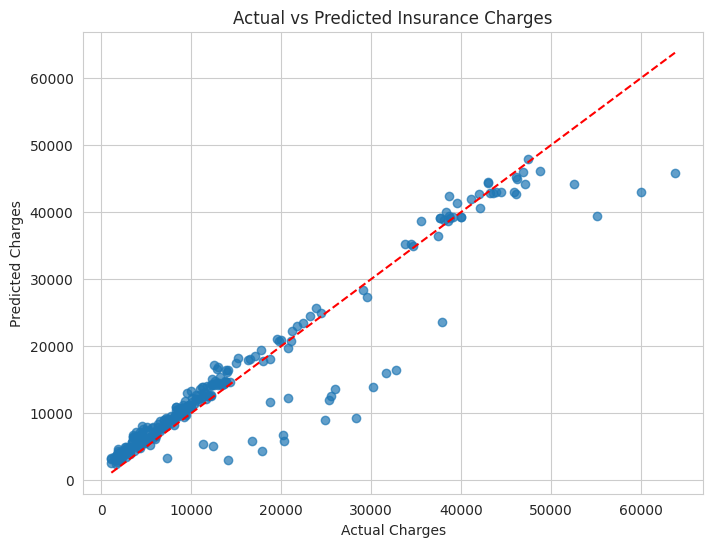

In [90]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_best, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()

Residual Plot

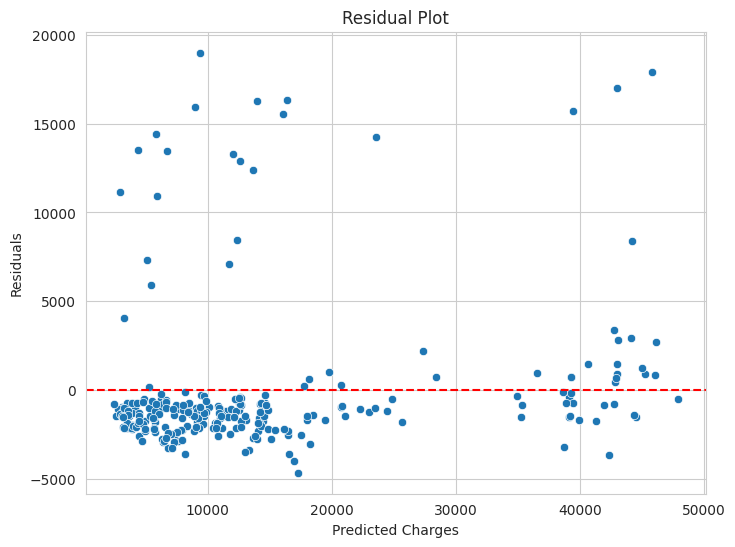

In [91]:
residuals = y_test - y_pred_best

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred_best, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

identifying important features

In [93]:
feature_names = preprocessor.get_feature_names_out()
importances = best_gb.named_steps['model'].feature_importances_
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
1,cat__smoker_yes,0.675602
6,remainder__bmi,0.184615
5,remainder__age,0.123107
7,remainder__children,0.014197
0,cat__sex_male,0.001166
4,cat__region_southwest,0.000999
3,cat__region_southeast,0.000169
2,cat__region_northwest,0.000145


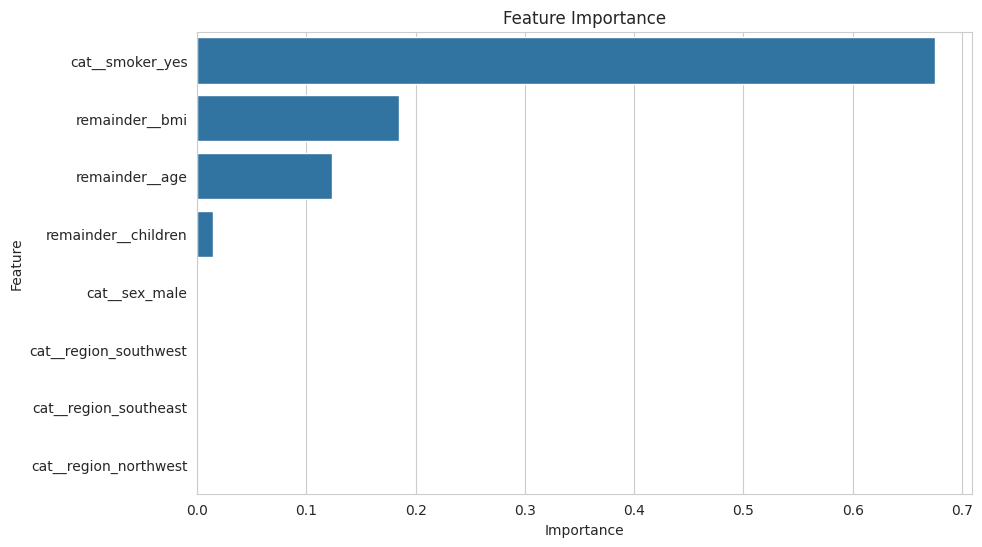

In [94]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")
plt.show()

Saving The Model

In [95]:
import pickle

with open("InsuranceCostPredictionModel.pkl", "wb") as file:
    pickle.dump(best_gb, file)

print("Model saved successfully.")

Model saved successfully.


## Model Comparison Report

Several regression algorithms were trained and evaluated to predict insurance charges. The models compared were Linear Regression, Ridge Regression, Lasso Regression, Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor, and XGBoost Regressor. Their performance was measured using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

Linear Regression served as the baseline model and achieved an R² Score of approximately 0.81. Ridge and Lasso Regression produced almost identical results, indicating that regularization did not significantly improve the performance of the linear model on this dataset. These models were able to capture the overall trend but were less effective in learning the complex relationships between the input features and insurance charges.

The Decision Tree Regressor improved the prediction accuracy compared to the linear models by capturing nonlinear patterns. However, its performance was lower than the ensemble-based methods, suggesting that a single decision tree was more prone to overfitting.

Random Forest Regressor further improved the results by combining multiple decision trees, reducing overfitting and providing better prediction accuracy. It achieved an R² Score of approximately 0.88, making it a strong performer on the dataset.

Gradient Boosting Regressor produced the best overall performance among all the models tested. After hyperparameter tuning, it achieved an R² Score of 0.9025 with the lowest RMSE, indicating that it was able to explain over 90% of the variation in insurance charges while maintaining the smallest prediction error. XGBoost also performed well but did not surpass the tuned Gradient Boosting model on this dataset.

Based on the evaluation results, the tuned Gradient Boosting Regressor was selected as the final model for production. It consistently provided the highest predictive accuracy and the best balance between model performance and generalization, making it the most suitable choice for predicting insurance costs.


## Report on Challenges Faced and Techniques Used

The first step of the project involved understanding the dataset and verifying its quality. Although the dataset was relatively clean, it was necessary to check for missing values, duplicate records, and incorrect data types before building any machine learning models. This ensured that the data used for training was reliable.

Another challenge was handling categorical variables such as gender, smoking status, and region, since machine learning algorithms require numerical input. To address this, One-Hot Encoding was applied, allowing the categorical information to be represented without introducing any artificial ordering between categories.

Selecting the most suitable regression algorithm was another important part of the project. Instead of relying on a single model, multiple regression techniques were trained and evaluated, including Linear Regression, Ridge Regression, Lasso Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost. Comparing several models made it possible to identify the algorithm that best captured the relationship between the input features and insurance charges.

The initial results showed that ensemble learning methods performed better than traditional linear regression models. To further improve the performance of the best-performing model, hyperparameter tuning was carried out on the Gradient Boosting Regressor. This resulted in a slight improvement in the R² Score and a reduction in prediction error, leading to a more accurate final model.

Finally, the models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. Using multiple evaluation metrics provided a more complete understanding of each model's performance and helped in selecting the most suitable model for production.
